# 04 · Machine Learning — ronda 1
Validación walk-forward en `VALID_T = [7, 8, 9, 10]`. La caja fuerte (t=11) **no se abre** aquí (R11). Todo número sale de `reports/experimentos.csv`, `reports/tuning/*.json` y `outputs/oof_*.parquet`.

In [1]:
import os, json, sys
os.chdir('..') if os.path.basename(os.getcwd()) == 'notebooks' else None
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config as C
from src.validation import metrica
exp = pd.read_csv('reports/experimentos.csv')
cols = ['nombre','modelo','familias','gini_t7','gini_t8','gini_t9','gini_t10','gini_medio','gini_std']

## 1. Diagnóstico: ¿dónde está la señal?
Logística contra LightGBM por defecto. Brecha de ~0,017: hay interacciones (umbrales por banda de riesgo).

In [2]:
exp[exp.nombre.isin(['diag_logreg','diag_logreg_base','diag_lgbm_base','smoke_lgbm'])][cols]

,nombre,modelo,familias,gini_t7,gini_t8,gini_t9,gini_t10,gini_medio,gini_std
0,smoke_lgbm,lgbm,supervivencia+interaccion+recencias,0.2542,0.2621,0.2515,0.2695,0.2593,0.0070
1,diag_logreg,logreg,supervivencia+interaccion+recencias,0.2441,0.2485,0.2305,0.2401,0.2408,0.0067
2,diag_lgbm_base,lgbm,NaN,0.2694,0.2595,0.2478,0.2619,0.2597,0.0077
3,diag_logreg_base,logreg,NaN,0.2476,0.2480,0.2345,0.2395,0.2424,0.0057


## 2. Campeón LightGBM con Optuna
Objetivo = Gini medio − 0,5 × desviación, `TPESampler(seed)`, tandas de 20 pruebas con storage sqlite.

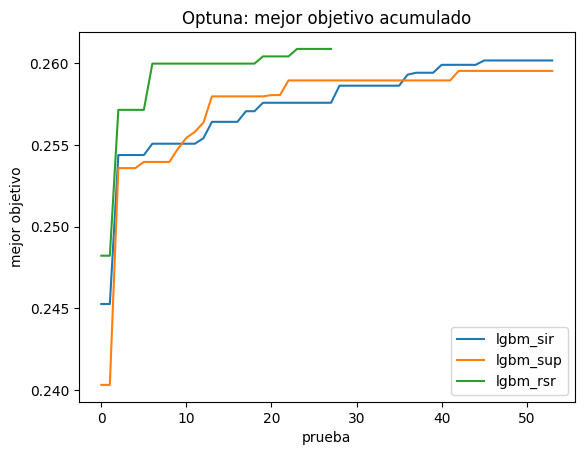

,estudio,familias,pruebas,media,std,objetivo
0,lgbm_sir,supervivencia+interaccion+recencias,54,0.2635,0.0067,0.2602
1,lgbm_sup,supervivencia,54,0.2638,0.0086,0.2595
2,lgbm_rsr,supervivencia+reglas_negocio+sin_ruido,28,0.2658,0.0099,0.2609


In [3]:
res = []
for f in ['lgbm_sir','lgbm_sup','lgbm_rsr']:
    j = json.load(open(f'reports/tuning/{f}.json'))
    res.append(dict(estudio=f, familias='+'.join(j['familias']), pruebas=j['trials'], media=round(j['best_media'],4), std=round(j['best_std'],4), objetivo=round(j['best_valor'],4)))
    v = pd.Series([p['valor'] for p in j['pruebas']]).cummax()
    plt.plot(v.values, label=f)
plt.xlabel('prueba'); plt.ylabel('mejor objetivo'); plt.legend(); plt.title('Optuna: mejor objetivo acumulado'); plt.show()
pd.DataFrame(res)

In [4]:
exp[exp.nombre.isin(['smoke_lgbm','lgbm_opt','lgbm_opt_s5','lgbm_opt_mono','lgbm_opt_reglas','lgbm_rsr_opt'])][cols]

,nombre,modelo,familias,gini_t7,gini_t8,gini_t9,gini_t10,gini_medio,gini_std
0,smoke_lgbm,lgbm,supervivencia+interaccion+recencias,0.2542,0.2621,0.2515,0.2695,0.2593,0.0070
4,lgbm_opt,lgbm,supervivencia+interaccion+recencias,0.2643,0.2703,0.2525,0.2669,0.2635,0.0067
5,lgbm_opt_s5,lgbm,supervivencia+interaccion+recencias,0.2643,0.2680,0.2517,0.2709,0.2637,0.0073
9,lgbm_opt_mono,lgbm,supervivencia+interaccion+recencias,0.2628,0.2733,0.2492,0.2702,0.2639,0.0093
19,lgbm_opt_reglas,lgbm,supervivencia+reglas_negocio+sin_ruido,0.2678,0.2748,0.2456,0.2643,0.2631,0.0108
22,lgbm_rsr_opt,lgbm,supervivencia+reglas_negocio+sin_ruido,0.2732,0.2707,0.2487,0.2707,0.2658,0.0099


Promediar 5 semillas (`lgbm_opt_s5`) confirma la mejora del tuning (+0,004 sobre `smoke_lgbm`). La monotonía (productos ↑, riesgo ↓, recencia ↓, app ↑, tarjeta ↑) deja el Gini igual (+0,0004) con más desviación: se acepta por explicabilidad, no por Gini.

## 3. Retadores por diversidad

In [5]:
exp[exp.nombre.isin(['gam_sup','hazard_dur_true','hazard_dur_false','hazard_reglas','logreg_reglas','de_logreg_reglas_sinruido'])][cols]

,nombre,modelo,familias,gini_t7,gini_t8,gini_t9,gini_t10,gini_medio,gini_std
8,de_logreg_reglas_sinruido,logreg,reglas_negocio+sin_ruido,0.2750,0.2759,0.2581,0.2618,0.2677,0.0079
11,hazard_dur_true,hazard,supervivencia,0.2438,0.2611,0.2555,0.2524,0.2532,0.0063
13,hazard_dur_false,hazard,supervivencia,0.2416,0.2632,0.2558,0.2517,0.2531,0.0078
15,gam_sup,gam,supervivencia,0.2413,0.2460,0.2233,0.2430,0.2384,0.0089
18,logreg_reglas,logreg,supervivencia+reglas_negocio+sin_ruido,0.2721,0.2750,0.2538,0.2611,0.2655,0.0085
21,hazard_reglas,hazard,supervivencia+reglas_negocio+sin_ruido,0.2671,0.2669,0.2506,0.2621,0.2617,0.0067


Con las reglas de negocio de DE (umbrales), la logística supera al boosting: los datos siguen reglas simples con umbral. El hazard discreto con splines no mejora a la logística lineal (más varianza).

## 4. Ensamble (promedio de rankings)

In [6]:
names = ['lgbm_opt_s5','lgbm_rsr_opt','logreg_reglas','hazard_reglas','de_logreg_reglas_sinruido','de_lgbm_sinruido']
o = {n: pd.read_parquet(f'outputs/oof_{n}.parquet') for n in names}
r = pd.DataFrame({n: o[n].groupby('t')['p'].rank(pct=True).values for n in names})
r.corr().round(3)

,lgbm_opt_s5,lgbm_rsr_opt,logreg_reglas,hazard_reglas,de_logreg_reglas_sinruido,de_lgbm_sinruido
lgbm_opt_s5,1.000,0.943,0.899,0.910,0.894,0.954
lgbm_rsr_opt,0.943,1.000,0.944,0.948,0.946,0.915
logreg_reglas,0.899,0.944,1.000,0.976,0.989,0.870
hazard_reglas,0.910,0.948,0.976,1.000,0.969,0.881
de_logreg_reglas_sinruido,0.894,0.946,0.989,0.969,1.000,0.866
de_lgbm_sinruido,0.954,0.915,0.870,0.881,0.866,1.000


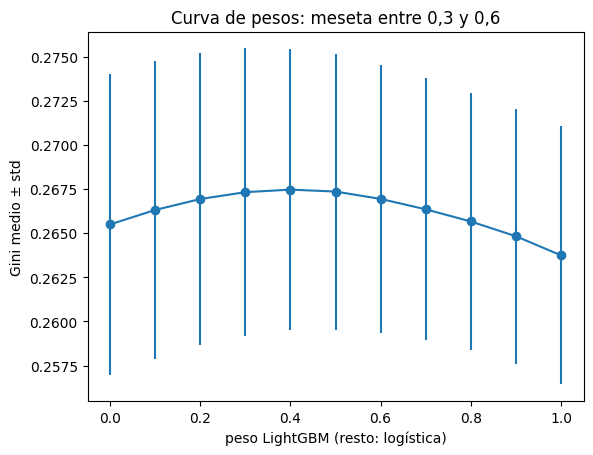

,nombre,modelo,familias,gini_t7,gini_t8,gini_t9,gini_t10,gini_medio,gini_std
16,de_ens_logreg_lgbm,rank_avg,de_logreg_reglas_sinruido+de_lgbm_sinruido,0.2743,0.2748,0.2563,0.2706,0.2690,0.0075
17,de_ens_logreg_smoke,rank_avg,de_logreg_reglas_sinruido+smoke_lgbm,0.2691,0.2728,0.2580,0.2684,0.2671,0.0055
20,ens_lgbm_logreg,rank_avg,lgbm_opt_s5+logreg_reglas,0.2720,0.2748,0.2544,0.2682,0.2674,0.0078
23,ens_rsr_logreg,rank_avg,lgbm_rsr_opt+logreg_reglas,0.2743,0.2744,0.2522,0.2674,0.2671,0.0090


In [7]:
y, t = o[names[0]].y.values, o[names[0]].t.values
def ev(p): g = [metrica(y[t==v], p[t==v]) for v in C.VALID_T]; return np.mean(g), np.std(g)
ws = np.linspace(0, 1, 11)
m = [ev(w*r.lgbm_opt_s5 + (1-w)*r.logreg_reglas) for w in ws]
plt.errorbar(ws, [a for a,b in m], yerr=[b for a,b in m], marker='o'); plt.xlabel('peso LightGBM (resto: logística)'); plt.ylabel('Gini medio ± std'); plt.title('Curva de pesos: meseta entre 0,3 y 0,6'); plt.show()
exp[exp.modelo=='rank_avg'][cols].drop_duplicates('nombre', keep='last')

La curva es plana entre 0,3 y 0,6: se usan **pesos iguales** (no se sobreajustan pesos a 4 folds).

## 5. SHAP del campeón LightGBM
Se entrena con t ≤ 10 (sin la caja fuerte) y se explica el mes t=10.

Gini t=10: 0.2687


/Users/pobidau/UTEC/DataFest coding test/.venv/lib/python3.9/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


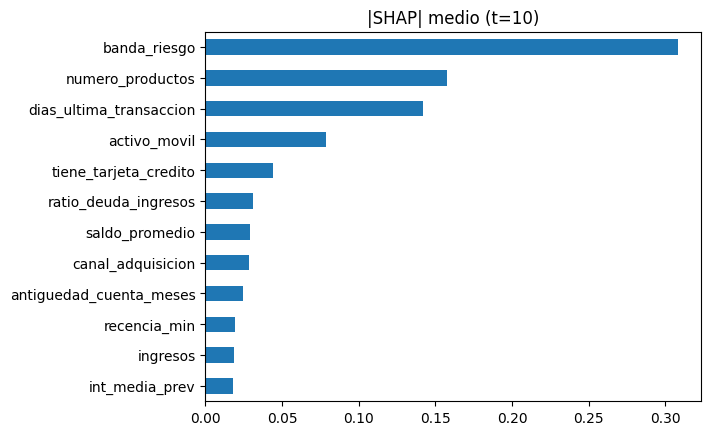

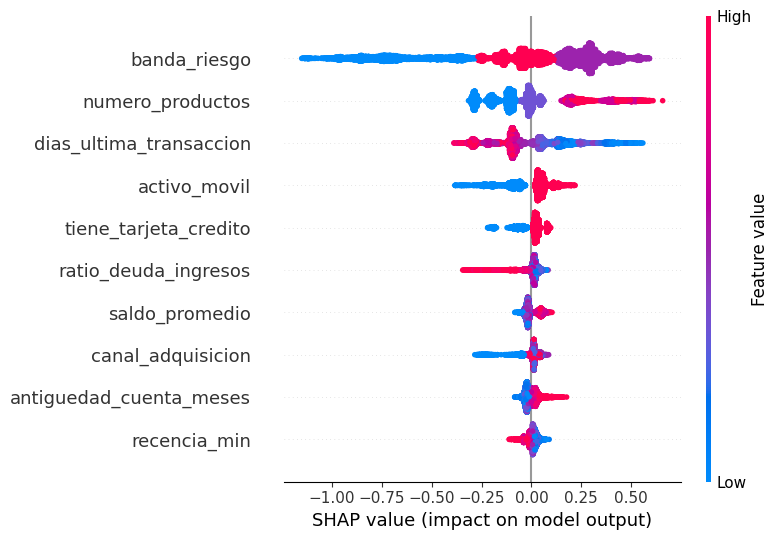

In [8]:
import shap, lightgbm as lgb
from src.features import construir
P = json.load(open('reports/tuning/lgbm_sir.json'))['best_params']
df, cols_f = construir(['supervivencia','interaccion','recencias'])
feats = [c for k in cols_f for c in cols_f[k]]
cats = [c for c in feats if str(df[c].dtype) == 'category']
X = df[feats].copy()
for c in cats: X[c] = X[c].cat.codes
tr = (df.es_test == 0) & (df.t < 10); va = (df.es_test == 0) & (df.t == 10)
m = lgb.LGBMClassifier(random_state=C.SEED, n_jobs=C.N_JOBS, verbose=-1, **P).fit(X[tr], df.objetivo[tr], categorical_feature=cats)
p10 = m.predict_proba(X[va])[:, 1]
print('Gini t=10:', round(metrica(df.objetivo[va], p10), 4))
sv = shap.TreeExplainer(m).shap_values(X[va])
sv = sv[1] if isinstance(sv, list) else sv
imp = pd.Series(np.abs(sv).mean(0), index=feats).sort_values(ascending=False)
imp.head(12)[::-1].plot.barh(title='|SHAP| medio (t=10)'); plt.show()
shap.summary_plot(sv, X[va], max_display=10, show=False); plt.show()

### Perfiles de los deciles 1 (más propensos) y 10

In [9]:
d = df[va].copy(); d['p'] = p10
d['decil'] = pd.qcut(d.p.rank(method='first', ascending=False), 10, labels=range(1, 11))
perf = d[d.decil.isin([1, 10])].groupby('decil', observed=True).agg(
    tasa_real=('objetivo','mean'), p_media=('p','mean'), productos=('numero_productos','mean'),
    riesgo_low=('banda_riesgo', lambda s: (s=='low').mean()), riesgo_high=('banda_riesgo', lambda s: (s=='high').mean()),
    dias_trans=('dias_ultima_transaccion','mean'), app=('activo_movil','mean'), tarjeta=('tiene_tarjeta_credito','mean'),
    meses_panel=('meses_previos','mean'))
print('lift decil 1:', round(perf.tasa_real.iloc[0] / d.objetivo.mean(), 2))
perf.round(3).T

lift decil 1: 2.16


decil,1,10
tasa_real,0.338,0.055
p_media,0.279,0.048
productos,3.033,1.812
riesgo_low,1.000,0.000
riesgo_high,0.000,0.999
dias_trans,166.505,290.645
app,0.785,0.644
tarjeta,0.788,0.762
meses_panel,2.438,5.784


## 6. Conclusiones
- Campeón individual: LightGBM afinado (`lgbm_opt_s5`, 0,2637 ± 0,0073; `lgbm_rsr_opt` 0,2658 ± 0,0099).
- La logística con reglas de negocio (0,2655–0,2677) empata o supera al boosting y es otra forma de error (correlación de rankings ~0,90).
- El ensamble logística + LightGBM es el mejor y más estable: 0,2674–0,2690.
- Ver `reports/ml.md`.